In [1]:
import pandas as pd
import numpy as np

from sklearn.svm import SVC
from sklearn.metrics import classification_report, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    
)

In [3]:
from sklearn.compose import ColumnTransformer

In [ ]:
file = r'/merged_flight_weather.csv'

In [5]:
data = pd.read_csv(file)

In [6]:
data['target'] = (data["cancelled_code"] != "N").astype(int)
data = data.drop(columns='cancelled_code')

In [7]:
print(data['target'].value_counts(normalize=True))

target
0    0.984264
1    0.015736
Name: proportion, dtype: float64


In [8]:
# set numerical and cetegorical features

categorical_features = [
    "carrier_code",
    "origin_airport",
    "destination_airport"
]

numerical_features = [
    "scheduled_elapsed_time",
    "departure_delay",
    "arrival_delay",
    "delay_carrier",
    "delay_weather",
    "delay_national_aviation_system",
    "delay_security",
    "delay_late_aircarft_arrival",
    "month",
    "day",
    "weekday",
    "HourlyDryBulbTemperature_x",
    "HourlyPrecipitation_x",
    "HourlyStationPressure_x",
    "HourlyVisibility_x",
    "HourlyWindSpeed_x",
    "HourlyDryBulbTemperature_y",
    "HourlyPrecipitation_y",
    "HourlyStationPressure_y",
    "HourlyVisibility_y",
    "HourlyWindSpeed_y",
    
]

features = categorical_features + numerical_features

In [9]:
data_new = data.copy()[features]

In [10]:
data_new['target']=data['target']

In [11]:
data_new.columns

Index(['carrier_code', 'origin_airport', 'destination_airport',
       'scheduled_elapsed_time', 'departure_delay', 'arrival_delay',
       'delay_carrier', 'delay_weather', 'delay_national_aviation_system',
       'delay_security', 'delay_late_aircarft_arrival', 'month', 'day',
       'weekday', 'HourlyDryBulbTemperature_x', 'HourlyPrecipitation_x',
       'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x',
       'HourlyDryBulbTemperature_y', 'HourlyPrecipitation_y',
       'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y',
       'target'],
      dtype='str')

In [12]:
# exclude outliers and re mask data

weather_cols = [
    "HourlyDryBulbTemperature_x",
    "HourlyPrecipitation_x",
    "HourlyStationPressure_x",
    "HourlyVisibility_x",
    "HourlyWindSpeed_x",
    "HourlyDryBulbTemperature_y",
    "HourlyPrecipitation_y",
    "HourlyStationPressure_y",
    "HourlyVisibility_y",
    "HourlyWindSpeed_y"
]

# 1. Calculate limits using weather data
lower = data[weather_cols].quantile(0.001)
upper = data[weather_cols].quantile(0.999)

# 2. Create mask based ONLY on weather variables
mask_outliers = (
    (data[weather_cols] >= lower) &
    (data[weather_cols] <= upper)
).all(axis=1)

In [13]:
# 3. Apply the mask to the COMPLETE dataset
data_filtered = data_new.copy().loc[mask_outliers]

In [14]:
data_filtered.columns

Index(['carrier_code', 'origin_airport', 'destination_airport',
       'scheduled_elapsed_time', 'departure_delay', 'arrival_delay',
       'delay_carrier', 'delay_weather', 'delay_national_aviation_system',
       'delay_security', 'delay_late_aircarft_arrival', 'month', 'day',
       'weekday', 'HourlyDryBulbTemperature_x', 'HourlyPrecipitation_x',
       'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x',
       'HourlyDryBulbTemperature_y', 'HourlyPrecipitation_y',
       'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y',
       'target'],
      dtype='str')

In [15]:
# create a subsample
data_sample, _ = train_test_split(
    data_filtered,
    train_size=10_000,
    stratify=data_filtered['target'],
    random_state=42
)

In [16]:
data_sample['target'].value_counts()

target
0    9847
1     153
Name: count, dtype: int64

In [17]:
print(data_sample.shape)
print(data_sample['target'].value_counts(normalize=True))

(10000, 25)
target
0    0.9847
1    0.0153
Name: proportion, dtype: float64


In [18]:
y = data_sample['target']
X = data_sample.copy().drop(columns='target')


In [19]:
X.columns

Index(['carrier_code', 'origin_airport', 'destination_airport',
       'scheduled_elapsed_time', 'departure_delay', 'arrival_delay',
       'delay_carrier', 'delay_weather', 'delay_national_aviation_system',
       'delay_security', 'delay_late_aircarft_arrival', 'month', 'day',
       'weekday', 'HourlyDryBulbTemperature_x', 'HourlyPrecipitation_x',
       'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x',
       'HourlyDryBulbTemperature_y', 'HourlyPrecipitation_y',
       'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y'],
      dtype='str')

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [21]:
X_train.columns

Index(['carrier_code', 'origin_airport', 'destination_airport',
       'scheduled_elapsed_time', 'departure_delay', 'arrival_delay',
       'delay_carrier', 'delay_weather', 'delay_national_aviation_system',
       'delay_security', 'delay_late_aircarft_arrival', 'month', 'day',
       'weekday', 'HourlyDryBulbTemperature_x', 'HourlyPrecipitation_x',
       'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x',
       'HourlyDryBulbTemperature_y', 'HourlyPrecipitation_y',
       'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y'],
      dtype='str')

In [22]:
models = {
    "Support Vector": SVC(probability=True, class_weight='balanced'),

}

numeric_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [26]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability for ROC-AUC
    # y_prob = pipeline[1].predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    # roc_auc = roc_auc_score(
    #     y_test,
    #     y_prob
    # )

    # Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        # "ROC-AUC": roc_auc
    })

    print(name, "trained")


/opt/miniconda3/envs/ML_bootcamp/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector trained


In [27]:
y_score = pipeline.decision_function(X_test)

auc = roc_auc_score(y_test, y_score)

print(f"SVC ROC AUC = {auc:.3f}")


SVC ROC AUC = 0.758


In [28]:
from sklearn.metrics import roc_curve

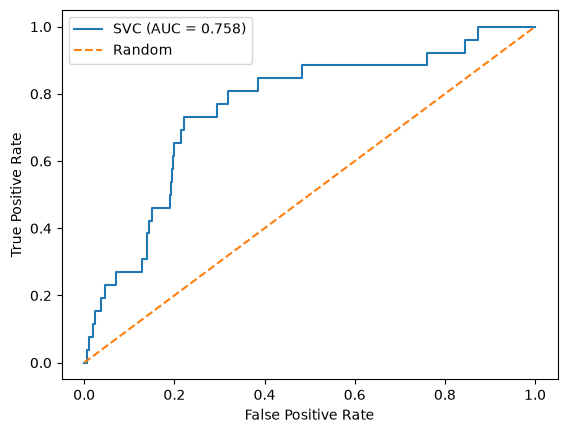

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

plt.plot(fpr, tpr, label=f"SVC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [30]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df = results_df.reset_index(drop=True)

print("\nModel Performance:")
print(results_df.round(4))


Model Performance:
            Model  Accuracy  Precision  Recall  F1 Score
0  Support Vector     0.961     0.0667  0.1538     0.093


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1974
           1       0.07      0.15      0.09        26

    accuracy                           0.96      2000
   macro avg       0.53      0.56      0.54      2000
weighted avg       0.98      0.96      0.97      2000



In [ ]:
from yellowbrick.classifier import ROCAUC

In [ ]:
visualizer = ROCAUC(
        pipeline,
        classes=[0, 1],
        micro=False,
        macro=False
    )

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)

print(f"{name} ROC-AUC: {visualizer.roc_auc:.4f}")

visualizer.show()